In [1]:
import torch 
import torch.nn as nn
#turn off scientific notation
torch.set_printoptions(sci_mode=False)

import copy
import torch.nn.functional as F

import tqdm
from torch_linear_assignment import batch_linear_assignment, assignment_to_indices
from typing import List, Tuple, Dict, Any, Literal, Optional, Union

from src.utils.normalizer import Normalizer

from src.permute_compress import PermutedSparseWeight

/data/lliu/NoWAG/src/permute_compress.py:675: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path="../config/compress", config_name="permute")


In [2]:
# set CUDA_LAUNCH_BLOCKING=1
# to get the correct error message

! export CUDA_LAUNCH_BLOCKING=1

In [3]:
device = "cuda:7"

weight_path = "./models/meta-llama/Llama-2-7b-hf/original_weights/layer_0/mlp.down_proj.pt"
hessian_diag = weight_path.replace("original_weights", "hessianDiags/seed_0/pajama/128")


weight = torch.load(weight_path, map_location=device)["weight"].to(torch.float32).detach()
hessian_diag = torch.load(hessian_diag, map_location=device)["hessianDiag"].to(torch.float32    )


hessian_diag = hessian_diag/torch.median(hessian_diag)

normalizer, normalized_weight = Normalizer.normalize_init(weight, norm_order=[0,1], zero = [False, False])

In [4]:
11008/256

43.0

In [5]:
hessian_diag

tensor([1.4324, 0.8063, 2.8333,  ..., 1.7838, 0.7072, 1.6622], device='cuda:7')

In [6]:
torch.all(torch.isfinite(hessian_diag))

tensor(True, device='cuda:7')

In [7]:
weight.shape[0]/32

128.0

In [23]:
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

P = PermutedSparseWeight(original_weight=weight,
                            n_permutations_0=8,
                            n_permutations_1=8,
                            N=2,
                            M=4,
                            block_size=64,
                            initalize_method="Greedy",
                            importance_weight=hessian_diag
                            )
P.to(device)

l = [P.recon_loss(reduction="mean").item()]
print("initial loss", l[0])
optimizer = torch.optim.Adam(P.parameters(), lr=1e-4)
n_adam_steps = 10
n_permutation_to_change = 1
for i in range(100):

    # print(10*"==")


            
        #reinitalize a new optimizer
    for j in range(n_adam_steps):
        optimizer.zero_grad()
        loss = P.recon_loss(reduction="mean")
        loss.backward()
        optimizer.step()
        l.append(loss.item())
    if n_adam_steps > 0:
        print(f"loss after {n_adam_steps} steps = {loss.item()}")
        
    #randomly select a permutation to optimize
    with torch.no_grad():
        for j in range(n_permutation_to_change):
            prev_state_dict = copy.deepcopy(P.state_dict()) 
            #randomly select a dimension to optimize
            permutation_dim = 0 if torch.randint(0, 2, (1,)).item() == 0 else 1
            # permutation_dim = 1
            # print(f"Greedy optimizing permutation {permutation_dim}")

            prev_loss = P.recon_loss(reduction="mean")
            P.greedy_optimize_permutation(permutation_dim)
            new_loss = P.recon_loss(reduction="mean")
            # assert new_loss <= prev_loss + 1e-8, f"Loss should decrease but is {new_loss} > {prev_loss}"
            # print(f"prev_loss = {prev_loss.item()}, new_loss = {new_loss.item()}")
            if new_loss/prev_loss - 1 >  1e-3:
                print("Loss increased, reverting to previous state")
                P.load_state_dict(prev_state_dict)
                assert P.recon_loss() == prev_loss, f"Loss should be the same but is {P.recon_loss()} != {prev_loss}"
                # P.load_state_dict(prev_state_dict)
                # print("prev_loss", prev_loss.item())
                # print("new_loss", new_loss.item())
            else:
                l.append(new_loss.item())
            # break
            # break
            # assert new_loss <= prev_loss + 1e-8, f"Loss should decrease but is {new_loss} > {prev_loss}"
            # break
            # l.append(new_loss.item())
    print("loss", l[-1])
    # raise Exception("stop")

initial loss 0.06186404824256897
loss after 10 steps = 0.06182239204645157
loss 0.061692532151937485
loss after 10 steps = 0.0616006962954998
loss 0.06157459318637848
loss after 10 steps = 0.061515066772699356
loss 0.06142919510602951
loss after 10 steps = 0.06134641170501709
loss 0.061278071254491806
loss after 10 steps = 0.06120270863175392
loss 0.06118877977132797
loss after 10 steps = 0.06113453209400177
loss 0.06108289584517479
loss after 10 steps = 0.06101079657673836
loss 0.060999974608421326
loss after 10 steps = 0.060952238738536835
loss 0.06094279885292053
loss after 10 steps = 0.06089789792895317
loss 0.06088235229253769
loss after 10 steps = 0.06084403395652771
loss 0.06083665415644646
loss after 10 steps = 0.06080349534749985
loss 0.06078927591443062
loss after 10 steps = 0.06075960770249367
loss 0.060726188123226166
loss after 10 steps = 0.06067778542637825
loss 0.060673873871564865
loss after 10 steps = 0.060652390122413635
loss 0.06065010279417038
loss after 10 steps = 

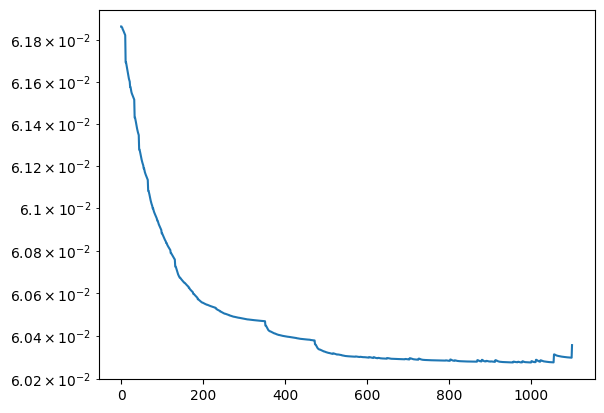

In [24]:
import matplotlib.pyplot as plt 
plt.plot(l)
plt.yscale("log")
# plt.xscale("log")

In [25]:
P()

tensor([[     0.0002,     -0.0137,      0.0085,  ...,     -0.0174,
             -0.0002,      0.0011],
        [     0.0013,      0.0000,      0.0091,  ...,      0.0015,
              0.0026,      0.0326],
        [    -0.0006,      0.0339,     -0.0001,  ...,     -0.0009,
             -0.0014,      0.0169],
        ...,
        [    -0.0086,      0.0018,      0.0007,  ...,      0.0231,
             -0.0006,      0.0301],
        [    -0.0181,      0.0378,      0.0011,  ...,     -0.0002,
              0.0004,     -0.0216],
        [     0.0127,     -0.0024,      0.0010,  ...,      0.0008,
             -0.0000,     -0.0295]], device='cuda:7', grad_fn=<ViewBackward0>)

In [26]:
P.original_weight

tensor([[ 0.0027, -0.0145,  0.0083,  ..., -0.0175, -0.0054,  0.0014],
        [ 0.0046, -0.0042,  0.0090,  ...,  0.0160, -0.0138,  0.0334],
        [ 0.0020,  0.0339, -0.0044,  ..., -0.0146,  0.0220,  0.0167],
        ...,
        [-0.0089, -0.0114,  0.0052,  ...,  0.0231, -0.0135,  0.0295],
        [-0.0177,  0.0374,  0.0090,  ..., -0.0069, -0.0122, -0.0219],
        [ 0.0120, -0.0013, -0.0079,  ..., -0.0003, -0.0030, -0.0302]],
       device='cuda:7')

In [27]:
P.permutations_0    

tensor([[   0,    1,    2,  ..., 4093, 4094, 4095],
        [  58,   46,   17,  ..., 4043, 4078, 4051],
        [  34,   30,   59,  ..., 4045, 4048, 4072],
        ...,
        [  31,   56,    1,  ..., 4082, 4084, 4061],
        [  55,   31,    4,  ..., 4080, 4043, 4062],
        [   3,   37,   10,  ..., 4050, 4091, 4040]], device='cuda:7')

In [22]:
P.c_1

Parameter containing:
tensor([[ 0.9950,  0.9902,  0.9974,  ...,  0.9965,  0.9945,  0.9916],
        [-0.0317, -0.0322, -0.0114,  ...,  0.0524, -0.0481, -0.0516],
        [ 0.0243,  0.0478,  0.0190,  ...,  0.0462, -0.0478, -0.0421],
        [ 0.0322, -0.0542, -0.0168,  ..., -0.0313, -0.0465, -0.0202]],
       device='cuda:7', requires_grad=True)

In [16]:
import torch

M = torch.tensor([[1, 2, 3],
                  [4, 5, 6],
                  [1, 2, 3]])

M = torch.stack([M, M], dim=0)

v = torch.tensor([1, 2, 3])

mask = (M == v.unsqueeze(0).unsqueeze(2)).all(dim=1)
print(mask)  # Output: tensor([ True, False,  True])

tensor([[False, False, False],
        [False, False, False]])


In [1]:
import torhc

ModuleNotFoundError: No module named 'torhc'

In [57]:
import torch

torch.manual_seed(0)

d_out, d_in = 128, 256
n_perms_0 = 8
n_perms_1 = 8

permutations_0 = torch.stack([torch.randperm(d_out) for _ in range(n_perms_0)], dim=0)
permutations_1 = torch.stack([torch.randperm(d_in) for _ in range(n_perms_1)], dim=0)

c_0 = torch.randn(n_perms_0, d_out)
c_1 = torch.randn(n_perms_1, d_in)

X = torch.randn(d_out, d_in)    


W_recon = torch.einsum("ijk,ij -> jk", torch.einsum("ijk, jk-> ik", X[:, permutations_1], c_1)[permutations_0], c_0)

# torch.einsum("ijk, jk-> ik", X[:, permutations_1], c_1)
# print(torch.einsum("ijk, ij-> jk", X[permutations_0,:], c_0))
# W_recon = torch.einsum("ijk, ij-> jk", W_recon[permutations_0,:], c_0)

W_recon_1 = torch.einsum("ijk, jk-> ik", torch.einsum("ijk, ij-> jk", X[permutations_0,:], c_0)[:, permutations_1], c_1)

assert torch.allclose(W_recon, W_recon_1, atol = 1e-5), f"reconstructions are not equal {W_recon} != {W_recon_1}"

A = torch.zeros(d_out, d_out)
for i in range(n_perms_0):
    print(A[torch.arange(d_out), permutations_0[i]].shape)
    A[torch.arange(d_out), permutations_0[i]] += c_0[i]
# A[permutations_0, torch.arange(d_out).view(1,-1)] = c_0

B = torch.zeros(d_in, d_in)
for j in range(n_perms_1):
    print(B[torch.arange(d_in), permutations_1[j]].shape)
    B[permutations_1[j], torch.arange(d_in)] += c_1[j]
    
# B[permutations_1, torch.arange(d_in).view(1,-1)] = c_1
# print(B)
# print(X @ B)
# print(A.T @ X)
W_recon_2 = A @ X @ B

torch.Size([128])
torch.Size([128])
torch.Size([128])
torch.Size([128])
torch.Size([128])
torch.Size([128])
torch.Size([128])
torch.Size([128])
torch.Size([256])
torch.Size([256])
torch.Size([256])
torch.Size([256])
torch.Size([256])
torch.Size([256])
torch.Size([256])
torch.Size([256])


In [58]:
torch.max(torch.abs(torch.einsum("ijk, ij-> jk", X[permutations_0,:], c_0)-A @ X))

tensor(2.8610e-06)

In [61]:
assert torch.allclose(W_recon, W_recon_2, atol=1e-5), f"Reconstructed weights are not close: {W_recon} != {W_recon_2}"